## **SALES ANALYSIS PROJECT**

### **Project statement:**
> AAL, established in 2000, is a well-known brand in Australia, particularly recognized for its clothing business. It has opened branches in various states, metropolises, and tier-1 and tier-2 cities across the country.
<br><br>The brand caters to all age groups, from kids to the elderly.
<br><br>Currently experiencing a surge in business, AAL is actively pursuing expansion opportunities. To facilitate informed investment decisions, the CEO has assigned the responsibility to the head of AAL’s sales and marketing (S&M) department. The specific tasks include:
1)	Identify the states that are generating the highest revenues.
2)	Develop sales programs for states with lower revenues. The head of sales and marketing has requested your assistance with this task.
Analyze the sales data of the company for the fourth quarter in Australia, examining it on a state-by-state basis. Provide insights to assist the company in making data-driven decisions for the upcoming year.


## **1. DATA WRANGLING**
>a. Ensure that the data is clean and free from any missing or incorrect entries.<br>
>  ○	Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().<br><br>
>b. Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).<br><br>
>c.	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)<br><br>
> d.Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.


### LOAD REQUIRED LIBRARIES

In [326]:
# import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler

### LOAD IN THE DATA

In [327]:
df = pd.read_csv("AusApparalSales4thQrt2020 2.csv")

# Check the first 5 rows of the DataFrame to ensure it loaded correctly
print(df.head())

         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500


### DATA INSPECTION

In [328]:

print("Column names in the DataFrame:")
print(df.columns)

print("\nData types of each column:")
print(df.dtypes)

print("\nThe shape of the DataFrame is:", df.shape)

# To preserve memory, downcast the integer columns to the smallest possible integer type to save memory
integer_columns = df.select_dtypes(include=["int"]).columns
df[integer_columns] = df[integer_columns].apply(pd.to_numeric, downcast="integer")

#To preserve memory, change the data column to datetime type
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# To preserve memory, downcast the object columns to the smallest possible object type to save memory
object_columns = df.select_dtypes(include=["object"]).columns
df[object_columns] = df[object_columns].apply(lambda x: x.astype("category") if x.nunique() / len(x) < 0.5 else x)

#trim all categorical columns to remove any leading or trailing whitespace
categorical_columns = df.select_dtypes(include=["category"]).columns
for col in categorical_columns:
    df[col] = df[col].str.strip()


#inspect the dataframe to see if there are missing/null values in all columns. 
#Check for min, max, mean, median, and quartiles for all columns. 
print("\nNumber of non-null values in each column:")
print(df.notna().sum())
print("\nNumber of null/missing values in each column:")
print(df.isna().sum())
print("\nNumber of duplicate rows")
print(df.duplicated().sum())
print("\nDescriptive statistics for unit and sales columns:")
print(df[["Unit","Sales"]].describe())

print("\nThe mean of the Sales column is:", df["Sales"].mean())
print("The median of the Sales column is:", df["Sales"].median())
print("The mode of the Sales column is:", df["Sales"].mode()[0])
print("The standard deviation of the Sales column is:", df["Sales"].std())
print("The minimum value of the Sales column is:", df["Sales"].min())
print("The maximum value of the Sales column is:", df["Sales"].max())

print("\nThe mean of the Unit column is:", df["Unit"].mean())
print("The median of the Unit column is:", df["Unit"].median())
print("The mode of the Unit column is:", df["Unit"].mode()[0])
print("The standard deviation of the Unit column is:", df["Unit"].std())
print("The minimum value of the Unit column is:", df["Unit"].min())
print("The maximum value of the Unit column is:", df["Unit"].max())

#Use the MinMaxScaler
scaler = MinMaxScaler()

#Scale the Sales column and create a new column
df[["Sales_normalized","Unit_normalized"]] = scaler.fit_transform(df[["Sales","Unit"]])

print("\nFirst 5 rows of the DataFrame after scaling the Unit and Sales columns:")
print(df.head())

#Group the data by State
state_grouped = df.groupby("State",observed=True)[["Sales"]].sum().reset_index()
print("\nTotal Sales by State:")
print(state_grouped)
#print the state with the highest and lowest total sales
print("\nThe state with the highest total sales is:", state_grouped.loc[state_grouped["Sales"].idxmax()]["State"], "with total sales of", state_grouped["Sales"].max())
print("The state with the lowest total sales is:", state_grouped.loc[state_grouped["Sales"].idxmin()]["State"], "with total sales of", state_grouped["Sales"].min())

#Group the data by Group
group_grouped = df.groupby("Group",observed=True)[["Sales"]].sum().reset_index()
print("\nTotal Sales by Group:")
print(group_grouped)


Column names in the DataFrame:
Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

Data types of each column:
Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

The shape of the DataFrame is: (7560, 6)

Number of non-null values in each column:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

Number of null/missing values in each column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Number of duplicate rows
0

Descriptive statistics for unit and sales columns:
              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000

The mean of the Sales column is: 45013.5582010582
The median 

### **DATA OBSERVATIONS**


The dataset contains **7,560 rows and six columns**, with 7,560 non-null values in every column. Therefore, there are no missing values that need to be removed, replaced, or estimated. Also there are **ZERO** duplicated rows.

##### **UNITS DATA ANALYSIS**
- The average units sold was 18.
- The median units sold was 14
- the most frequently occuring number was 9
- the standard deviation in the units sold column was 12.9 indicating a fair amount of variation in units sold
##### **SALES DATA ANALYSIS**
- The average sales amount was $45,014.
- The median sales amount was $35,0000
- the most frequently occuring sales amount was $22,500
- the standard deviation in the sales column was 32.253 indicating more amount of variation compared to units sold.

- The **Date, Time, State**, and **Group** columns are currently stored as object data types. For more efficient analysis, **Date** should be converted to a datetime type, while **Time, State**, and **Group** may be suitable as categorical variables. **Unit** and **Sales** are currently stored as int64 and would benefit being downcast to the smallest int possible.

- Grouped by **Group** (Kids, Men, Seniors, Women), the sales were fairly evenly distibuted. They each accounted for approximately 25% of total sales. This shows that age and gender do not really impact total sales.

- Grouped by **State** we get a different outcome. Victoria (VIC) had the highest sales total at $105,565,000 and accounted for 31% of total sales, while Western Australia (WA) had the lowest sales total at $22,152,500. That is a difference of $83,412,500. This suggests that location has a much greater impact on total sales than age and gender. 

In [329]:
#Add numerical columns for week, month and quarter to the DataFrame
df["Week"] = df["Date"].dt.isocalendar().week
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

#Weekly sales report numbers
df["Week_Ending"] = (df["Date"].dt.to_period("W-SUN").dt.end_time.dt.normalize())
weekly_sales = df.groupby("Week_Ending",observed=True)[["Sales"]].sum().reset_index()
#format the sales to be in AUD currency format
weekly_sales_formatted = weekly_sales.copy()
weekly_sales_formatted["Sales"] = weekly_sales_formatted["Sales"].map(lambda value: f"A${value:,.2f}")
print("\nTotal Sales by Week:")
print(weekly_sales_formatted)

#monthly sales report numbers
df["Month_Name"] = df["Date"].dt.month_name()
monthly_sales = (df.groupby(["Month", "Month_Name"],observed=True,as_index=False)["Sales"].sum().sort_values("Month")
)#format the sales to be in AUD currency format
monthly_sales_formatted = monthly_sales.copy()
monthly_sales_formatted["Sales"] = monthly_sales["Sales"].map(lambda value: f"A${value:,.2f}")
print("\nTotal Sales by Month:")
print(monthly_sales_formatted)

#monthly sales report numbers by group
monthly_sales_group = df.groupby(["Month_Name","Group"],observed=True)[["Sales"]].sum().reset_index()
#format the sales to be in AUD currency format
monthly_sales_group["Sales"] = monthly_sales_group["Sales"].map(lambda value: f"A${value:,.2f}")
print("\nTotal Sales by Month and Group:")
print(monthly_sales_group)

#quarterly sales report numbers
df["Quarter_Name"] = df["Date"].dt.to_period("Q").dt.strftime("Q%q %Y")
quarterly_sales = df.groupby("Quarter",observed=True)[["Sales"]].sum().reset_index()
#format the sales to be in AUD currency format
quarterly_sales_formatted = quarterly_sales.copy()
quarterly_sales_formatted["Sales"] = quarterly_sales_formatted["Sales"].map(lambda value: f"A${value:,.2f}")
print("\nTotal Sales by Quarter:")
print(quarterly_sales_formatted)





Total Sales by Week:
   Week_Ending            Sales
0   2020-10-04  A$15,045,000.00
1   2020-10-11  A$27,002,500.00
2   2020-10-18  A$26,640,000.00
3   2020-10-25  A$26,815,000.00
4   2020-11-01  A$21,807,500.00
5   2020-11-08  A$20,865,000.00
6   2020-11-15  A$21,172,500.00
7   2020-11-22  A$21,112,500.00
8   2020-11-29  A$21,477,500.00
9   2020-12-06  A$29,622,500.00
10  2020-12-13  A$31,525,000.00
11  2020-12-20  A$31,655,000.00
12  2020-12-27  A$31,770,000.00
13  2021-01-03  A$13,792,500.00

Total Sales by Month:
   Month Month_Name             Sales
0     10    October  A$114,290,000.00
1     11   November   A$90,682,500.00
2     12   December  A$135,330,000.00

Total Sales by Month and Group:
   Month_Name    Group            Sales
0    December     Kids  A$33,555,000.00
1    December      Men  A$34,250,000.00
2    December  Seniors  A$33,150,000.00
3    December    Women  A$34,375,000.00
4    November     Kids  A$22,882,500.00
5    November      Men  A$22,615,000.00
6    Novem

### **WEEKLY SALES CHART**

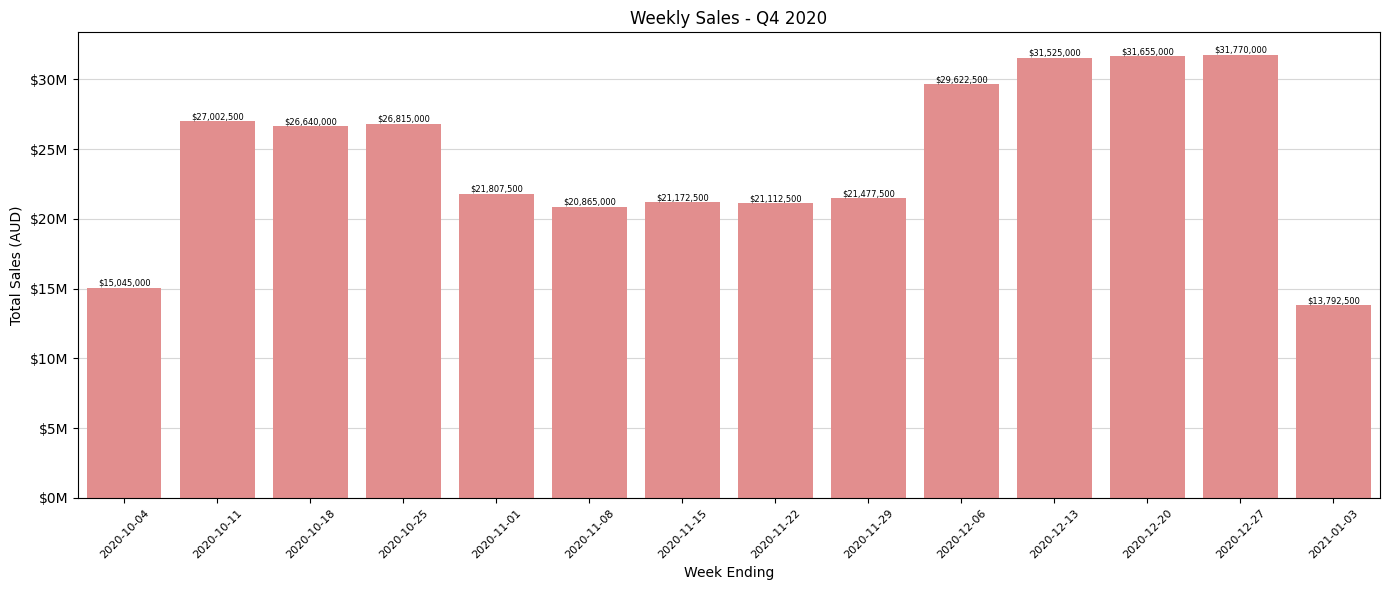

In [ ]:
#Visualize weekly sales using a bar chart
plt.figure(figsize=(14, 6))
ax = sns.barplot(x="Week_Ending", y="Sales", data=weekly_sales, color="lightcoral", errorbar=None)
#add sales totals on top of each bar
for index, row in weekly_sales.iterrows():
    ax.text(row.name, row.Sales, f'${row.Sales:,.0f}', color='black', ha="center", va="bottom", fontsize=6)
plt.title("Weekly Sales - Q4 2020")
plt.xlabel("Week Ending")
plt.xticks(
    rotation=45,
    fontsize=8
)
plt.ylabel("Total Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

plt.show()

### **MONTHLY SALES CHART**

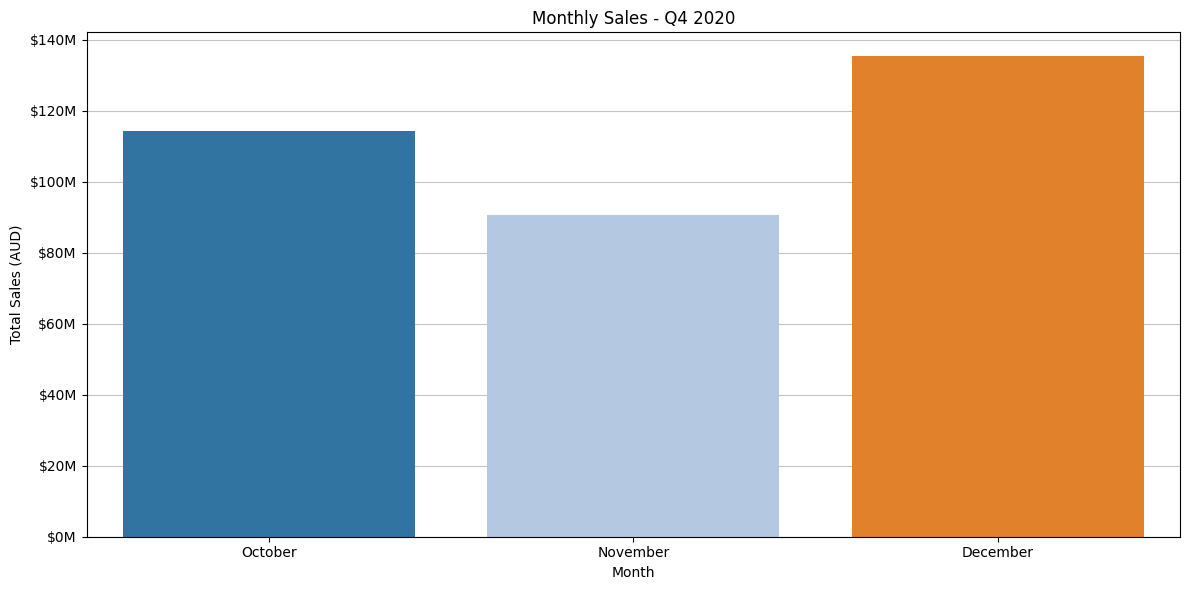

In [331]:
#Visualize monthly sales using a bar chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Month_Name", y="Sales", data=monthly_sales, hue="Month_Name", palette="tab20", errorbar=None)
plt.title("Monthly Sales - Q4 2020")
plt.xlabel("Month")
plt.ylabel("Total Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### **QUARTERLY SALES CHART**

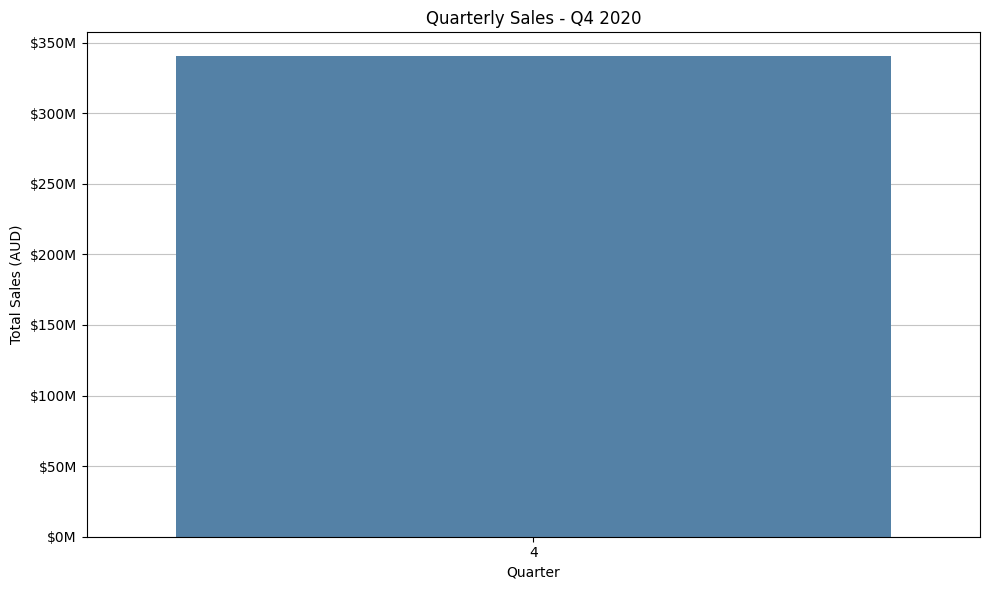

In [332]:
# Visualize quarterly sales using a bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(x="Quarter", y="Sales", data=quarterly_sales, color="steelblue", errorbar=None)
plt.title("Quarterly Sales - Q4 2020")
plt.xlabel("Quarter")
plt.ylabel("Total Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### **SALES BY GROUP AND BY DAY CHART**

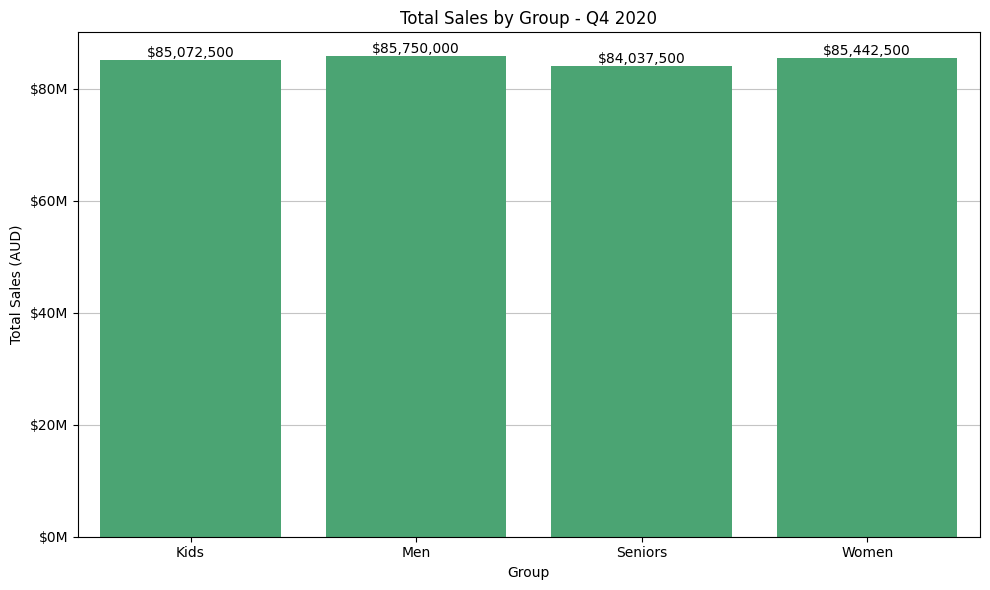

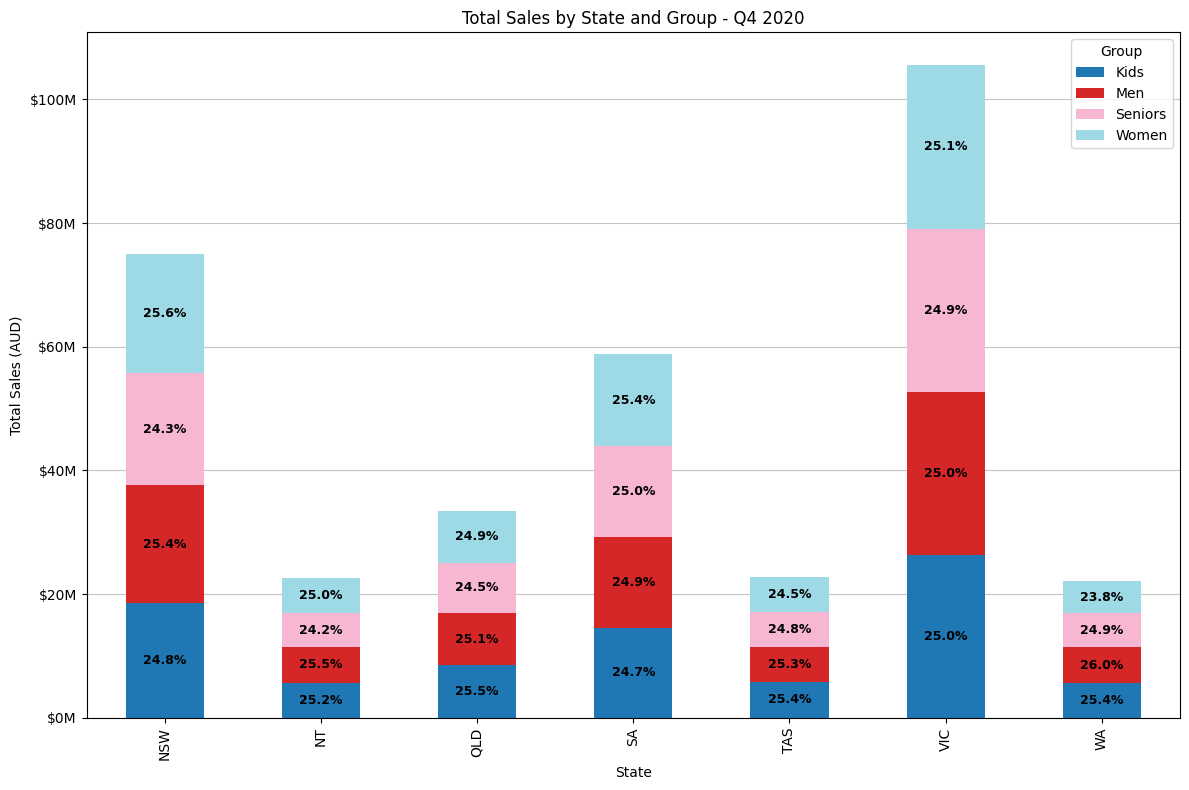

In [333]:
#visualize sales by group using a bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Group", y="Sales", data=group_grouped, color="mediumseagreen", errorbar=None)
for index, row in group_grouped.iterrows():
    ax.text(row.name, row.Sales, f'${row.Sales:,.0f}', color='black', ha="center", va="bottom", fontsize=10)
plt.title("Total Sales by Group - Q4 2020")
plt.xlabel("Group")
plt.ylabel("Total Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

#visualize sales by state broken out into groups using a stacked bar chart
state_grouped_group = df.groupby(["State","Group"],observed=True)[["Sales"]].sum().reset_index()
state_grouped_group_pivot = state_grouped_group.pivot(index="State", columns="Group", values="Sales").fillna(0)
ax = state_grouped_group_pivot.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")
# Calculate total sales for each state
state_totals = state_grouped_group_pivot.sum(axis=1)

# Add percentage labels to each stacked section
for container in ax.containers:
    labels = [
        f"{bar.get_height() / total:.1%}"
        if bar.get_height() > 0 else ""
        for bar, total in zip(container, state_totals)
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="black",
        fontsize=9,
        fontweight="bold"
    )
plt.title("Total Sales by State and Group - Q4 2020")
plt.xlabel("State")
plt.ylabel("Total Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### **SALES BY TIME OF DAY**


THE PEAK TIME OF DAY IS: Morning with total sales of A$114,207,500.00
THE OFF-PEAK TIME OF DAY IS: Evening with total sales of A$112,087,500.00

THE DIFFERENCE BETWEEN PEAK AND OFF-PEAK SALES IS: A$2,120,000.00


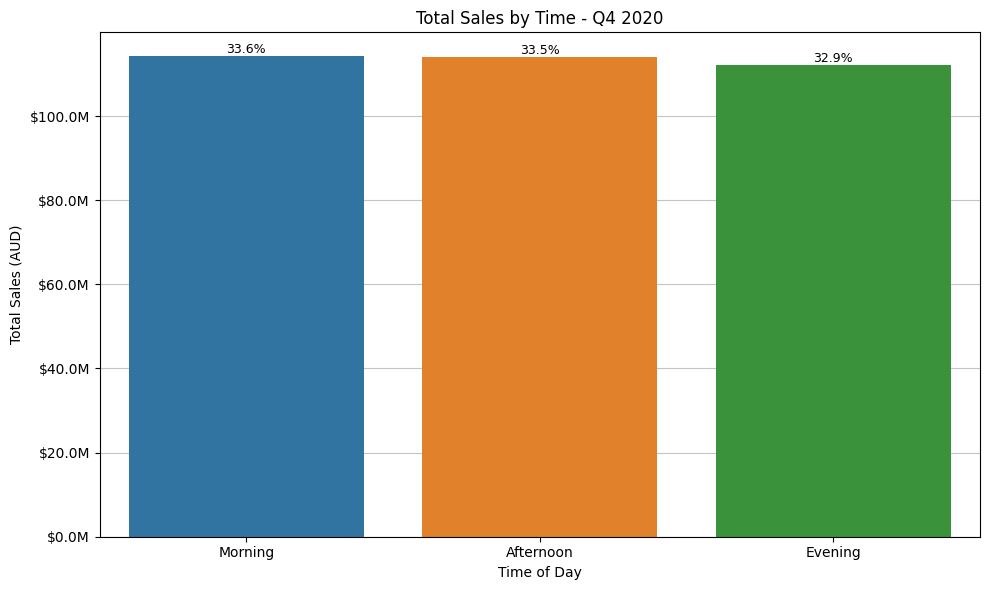

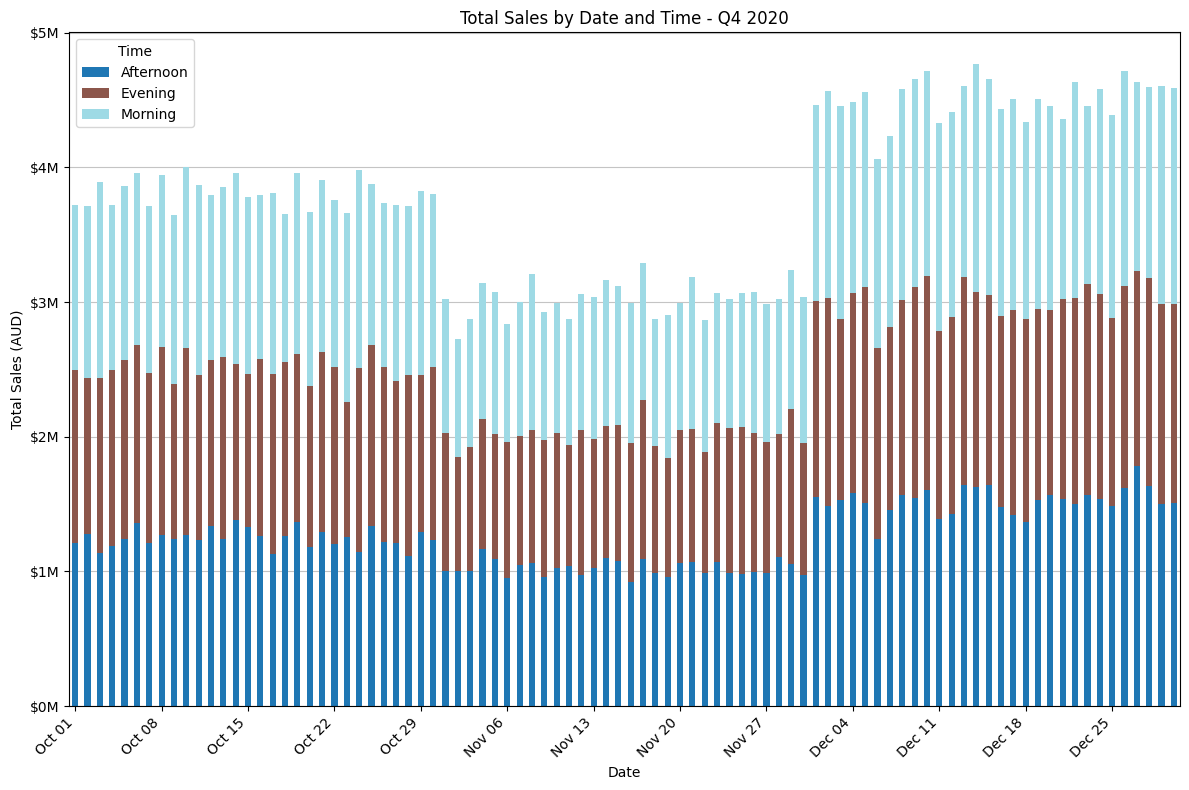

In [334]:
#Based on sales by time of day, calculate which time of day is peak and which one is off-peak. 
time_grouped = df.groupby(["Time"],observed=True)[["Sales"]].sum().reset_index()
peak_time = time_grouped.loc[time_grouped["Sales"].idxmax()]["Time"]
off_peak_time = time_grouped.loc[time_grouped["Sales"].idxmin()]["Time"]
peak_difference = time_grouped["Sales"].max() - time_grouped["Sales"].min()
print("\nTHE PEAK TIME OF DAY IS:", peak_time, "with total sales of", time_grouped["Sales"].map(lambda value: f"A${value:,.2f}").max())
print("THE OFF-PEAK TIME OF DAY IS:", off_peak_time, "with total sales of", time_grouped["Sales"].map(lambda value: f"A${value:,.2f}").min())
print("\nTHE DIFFERENCE BETWEEN PEAK AND OFF-PEAK SALES IS:", f"A${peak_difference:,.2f}")

#Visualize sales by time of day
time_grouped = df.groupby(["Time"],observed=True)[["Sales"]].sum().reset_index()
plt.figure(figsize=(10, 6))
time_order = ["Morning", "Afternoon", "Evening"]
time_grouped = time_grouped.set_index("Time").reindex(time_order).reset_index() 
ax = sns.barplot(x="Time", y="Sales", data=time_grouped, order=time_order, hue="Time", palette="tab10", errorbar=None, legend=False)

#add percentage labels of total sales for each time of day
total_sales = time_grouped["Sales"].sum()
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_sales:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.title("Total Sales by Time - Q4 2020")
plt.xlabel("Time of Day")
plt.ylabel("Total Sales (AUD)")

# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

#visualize sales by time grouped by date using a stacked bar chart
time_grouped_date = df.groupby(["Date","Time"],observed=True)[["Sales"]].sum().reset_index()
time_grouped_date_pivot = time_grouped_date.pivot(index="Date", columns="Time", values="Sales").fillna(0)
ax = time_grouped_date_pivot.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")
plt.title("Total Sales by Date and Time - Q4 2020")
plt.xlabel("Date")
plt.ylabel("Total Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000000:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
# Display one date label every seven days
interval = 7
positions = range(0, len(time_grouped_date_pivot), interval)

ax.set_xticks(list(positions))
ax.set_xticklabels(time_grouped_date_pivot.index[::interval].strftime("%b %d"),rotation=45,ha="right")
plt.tight_layout()
plt.show()

### **DISTRIBUTION OF SALES**

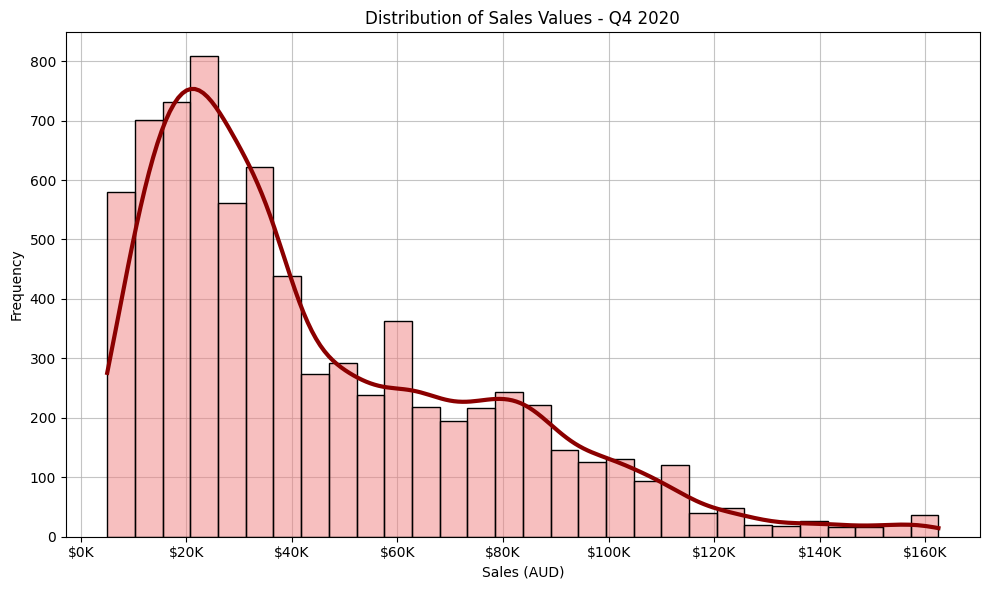

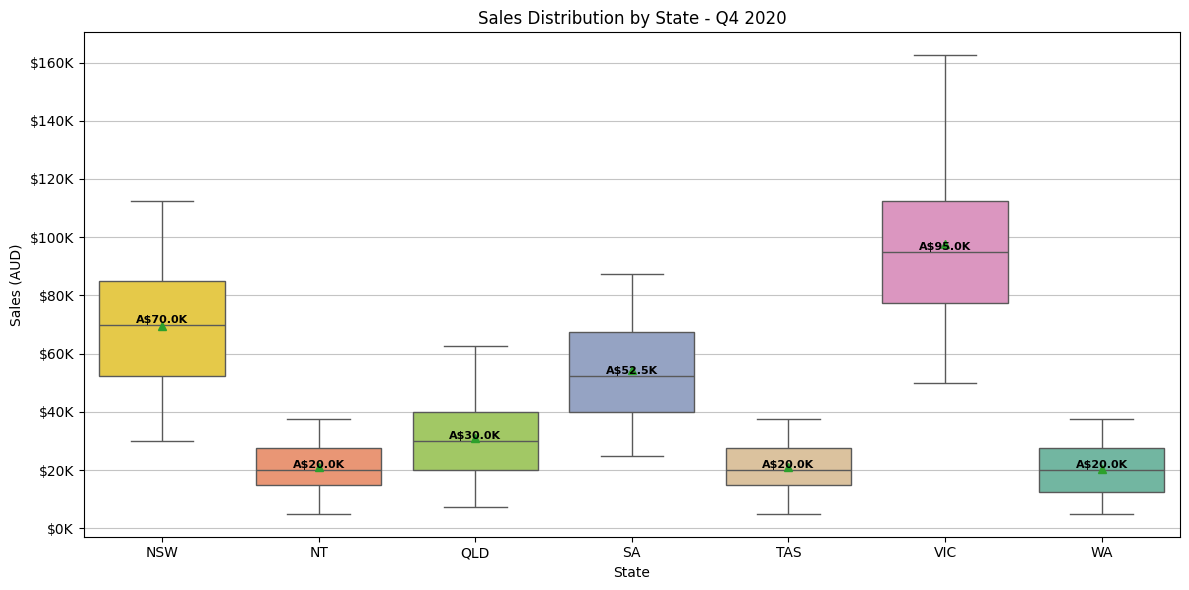

In [335]:
#Analyze the distribution of sales values.
plt.figure(figsize=(10, 6))
ax = sns.histplot(df["Sales"], bins=30, kde=True, edgecolor="black",color="lightcoral")
ax.lines[0].set_color("darkred")
ax.lines[0].set_linewidth(3)
plt.title("Distribution of Sales Values - Q4 2020")
plt.xlabel("Sales (AUD)")
plt.ylabel("Frequency")
# Format the x-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
plt.gca().xaxis.set_major_formatter(formatter)
ax.grid(axis="both", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()  






#BOXPLOT to visualize the sales distribution by state
plt.figure(figsize=(12, 6))

state_order = sorted(df["State"].unique())
ax = sns.boxplot(
    data=df,
    x="State",
    y="Sales",
    order=state_order,
    hue="State",
    palette="Set2",
    legend=False,
    showmeans=True
)

# Calculate and label medians
state_medians = df.groupby("State")["Sales"].median()

for position, state in enumerate(state_order):
    median = state_medians[state]

    ax.text(
        position,
        median,
        f"A${median / 1_000:,.1f}K",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="black"
    )

plt.title("Sales Distribution by State - Q4 2020")
plt.xlabel("State")
plt.ylabel("Sales (AUD)")
# Format the y-axis to display currency
formatter = FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
plt.gca().yaxis.set_major_formatter(formatter)
ax.grid(axis="y", linestyle="-", alpha=0.75)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## **OVERALL OBSERVATIONS AND RECOMMENDATIONS**

#### OBSERVATIONS
- The dataset is clean: all 7,560 records are complete, with no null values or duplicate rows. 
- Sales are strongly right-skewed. The mean is A$45,014, while the median is only A$35,000—showing that a smaller number of large transactions raise the average. 
- **Sales** also appear to equal **Unit** × A$2,500, which explains why their normalized values are identical
- Geography is the strongest differentiator: VIC generated A$105.57M (31% of total sales), followed by NSW at A$74.97M and SA at A$58.86M. Together, those three states produced about 70% of total sales. The boxplot confirms that this is not merely a volume difference: median transaction sales were approximately A$95K in Victoria, A$70K in NSW, and A$52.5K in SA, compared with about A$20K in NT, Tasmania, and WA. 
- Customer groups (Kids, Men, Women, Seniors), by contrast, were nearly even at approximately 25% each
- Time-of-day sales (Morning, Afternoon, Evening) were balanced at roughly 33% each
- There is little evidence that one demographic group or selling period deserves substantially more attention.

#### RECOMMENDATIONS
- The sales and marketing team should expand marketing and sales in the markets of VIC, NSW, and SA as they were the top 3 selling markets and accounted for almost 70% of total sales.
- In WA, NT, TAS, and QLD, the suggestion is to do a deep dive into the cause of the lower sales in these states. Once the cause is identified, then a more targeted marketing campaign can commence. 
- Sales fell from A$114.29M in October to A$90.68M in November, then surged to A$135.33M in December. More marketing dollars for the holiday season should be spent in October to try and prevent the slowdown in November
